# Face Recognition using CNN

This notebook demonstrates a compact convolutional neural network for identity classification on a public face dataset. The goal is to explain how a model can learn identity-specific visual features and why face detection and face recognition are different tasks.

## Understanding the Problem

Face recognition asks: “Who is this person?” Face detection asks: “Where are the faces in this image?” The two tasks are related but not identical. In this notebook, we focus on recognition: classifying identities from face images.

## Core Concept

A CNN learns patterns such as eyes, nose structure, and overall facial geometry. These patterns are compressed into feature maps and then mapped to a class label corresponding to a person.

## Mathematical Intuition

The convolution operation learns local patterns using kernels:

$$
Y = X * K + b
$$

where $X$ is the input image and $K$ is the filter. Pooling reduces dimensionality, while the final dense layer produces a class probability over identities.

## Data Preparation

We use a small public face dataset suitable for a learning environment. The images are normalized, reshaped, and split into training and validation folds before the model is trained.


janani


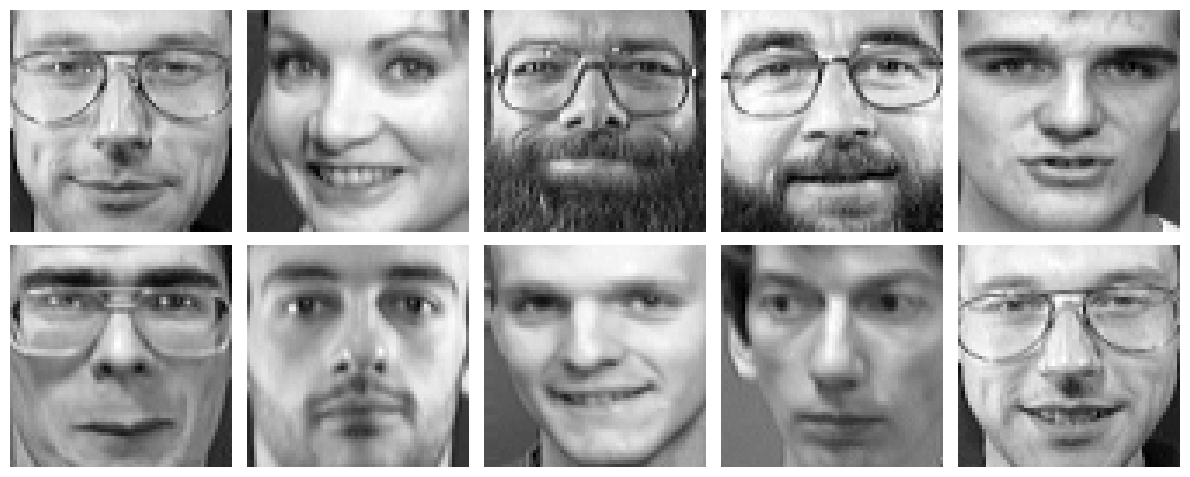

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │         5,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,629,736 (6.22 MB)

 Trainable params: 1,629,736 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.0174 - loss: 3.6929 - val_accuracy: 0.0000e+00 - val_loss: 3.6923
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.0278 - loss: 3.6891 - val_accuracy: 0.0000e+00 - val_loss: 3.6917
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.0278 - loss: 3.6888 - val_accuracy: 0.0000e+00 - val_loss: 3.6929
Epoch 4/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.0278 - loss: 3.6886 - val_accuracy: 0.0000e+00 - val_loss: 3.6941
Epoch 5/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.0278 - loss: 3.6885 - val_accuracy: 0.0000e+00 - val_loss: 3.6954


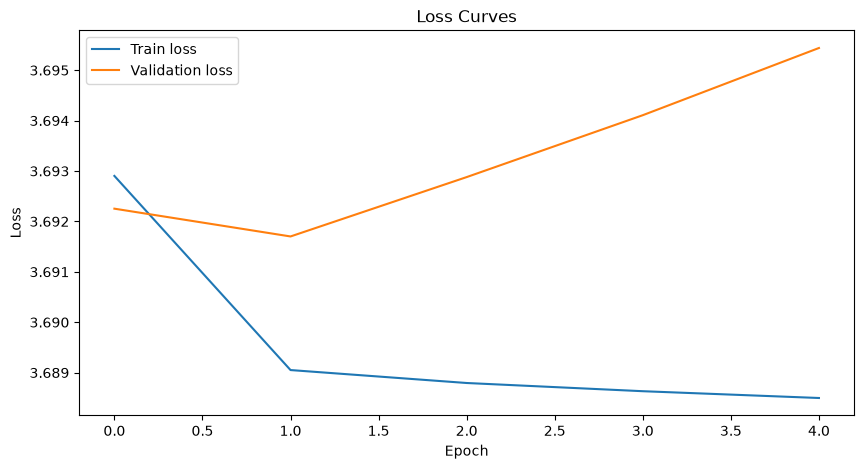

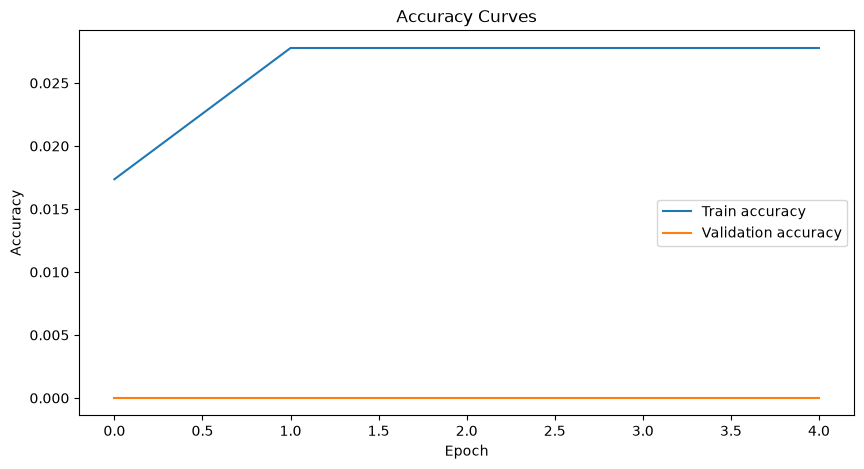

Test loss: 3.6889
Test accuracy: 0.0250


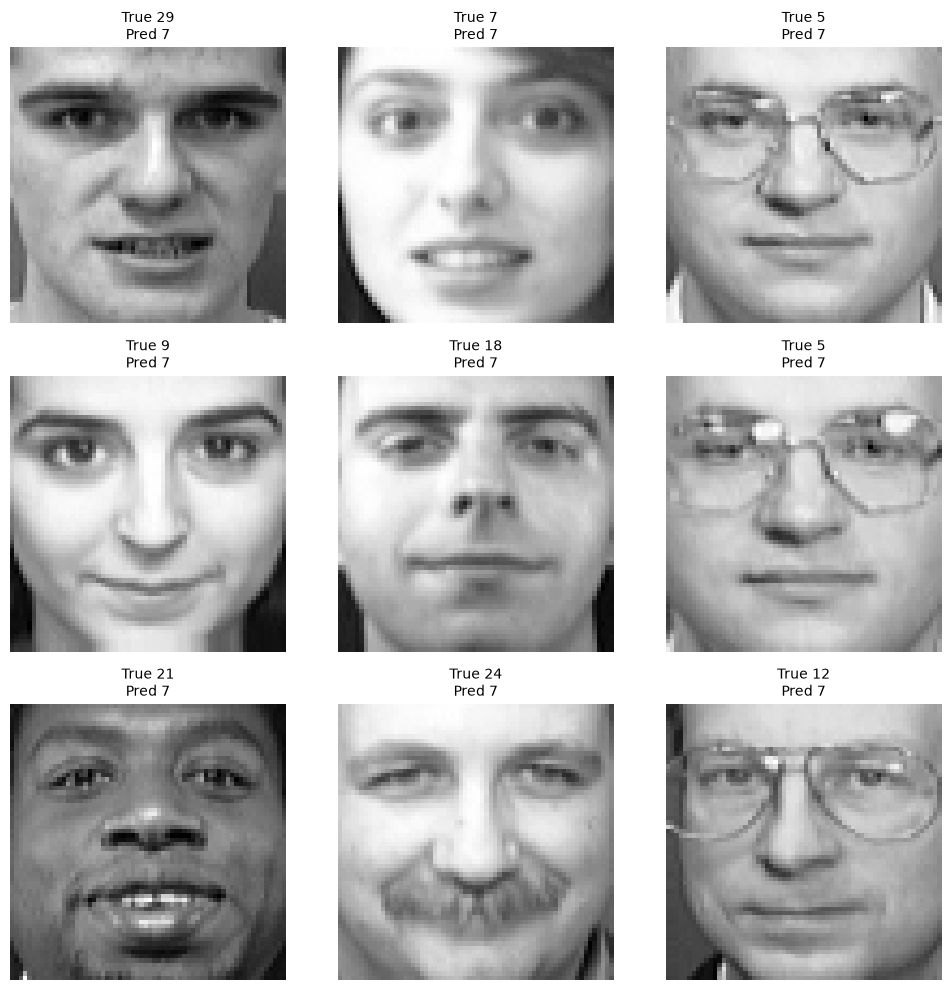

Face recognition differs from detection because it identifies a person, not simply whether a face exists and where it is located.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

# Load the dataset
faces, labels = fetch_olivetti_faces(return_X_y=True)

# Reshape to images and normalize
faces = faces.reshape(-1, 64, 64, 1).astype('float32') / 255.0

# Encode labels as categorical classes
labels = to_categorical(labels)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    faces,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

# Show sample faces
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, image in zip(axes.flat, X_train[:10]):
    ax.imshow(image.squeeze(), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()

# Build small CNN
model = models.Sequential([
    layers.Input(shape=(64, 64, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(labels.shape[1], activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=32,
    verbose=1
)

# Plot learning curves
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {loss:.4f}')
print(f'Test accuracy: {acc:.4f}')

# Sample predictions
pred_probs = model.predict(X_test, verbose=0)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = np.argmax(y_test, axis=1)

sample_idx = np.random.choice(len(X_test), 9, replace=False)
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for ax, idx in zip(axes.flat, sample_idx):
    image = X_test[idx].squeeze()
    pred = pred_labels[idx]
    true = true_labels[idx]
    ax.imshow(image, cmap='gray')
    ax.set_title(f'True {true}\nPred {pred}', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

print('Face recognition differs from detection because it identifies a person, not simply whether a face exists and where it is located.')
